# Case study: Groundwater monitoring

Peter Ralph  
2026-02-16

# Wastewater in Eugene

Our wastewater (sewer plus stormwater) in Eugene and Springfield is
treated by the [Metropolitan Wastewater Management
Commission](https://mwmcpartners.org/), in part at the [Biosolids
Management
Facility](https://mwmcpartners.org/facilities/biosolids-management-facility/)
(see slideshow on that page).

As part of their operating requirements, they monitor groundwater for
potential contamination: in 26 monitoring wells, since 1988.

Their biggest question: *how to best detect if the facility is affecting
the groundwater?*

**Note:** the MWMC is very much on top of this, and has no evidence of
groundwater contamination. This is being presented for pedagogical
purposes.

## What is measured?

<figure>
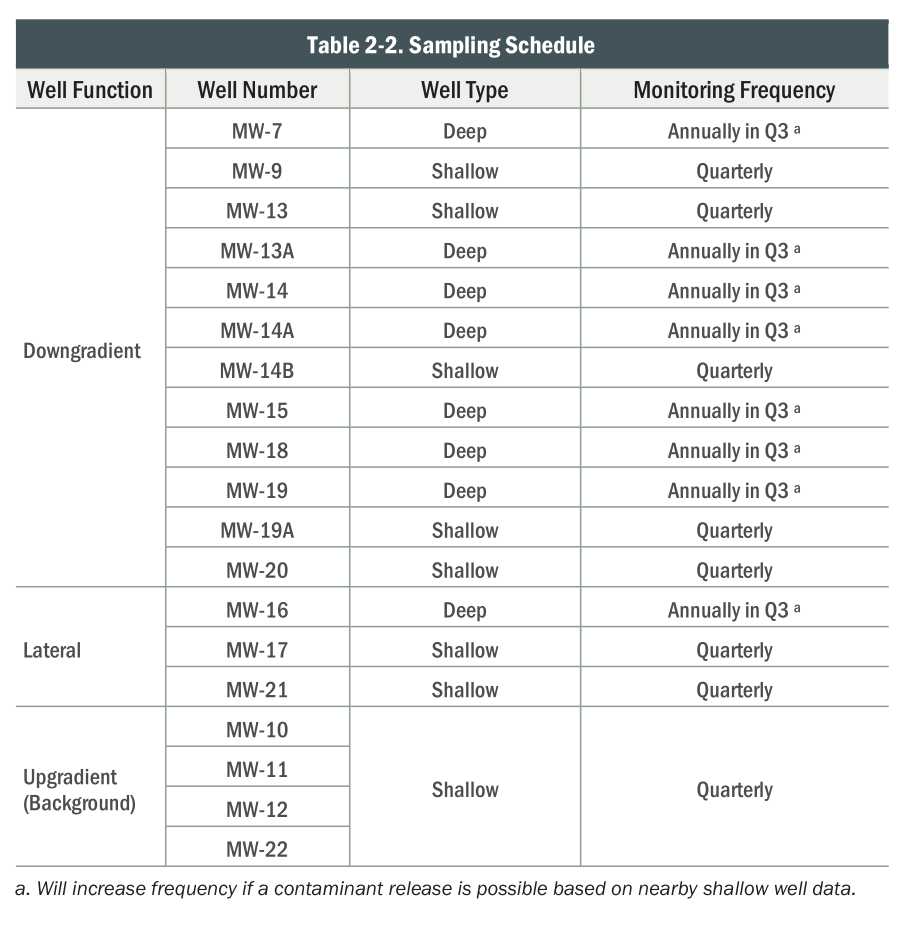
<figcaption aria-hidden="true">Table showing monitoring frequency for
each well</figcaption>
</figure>

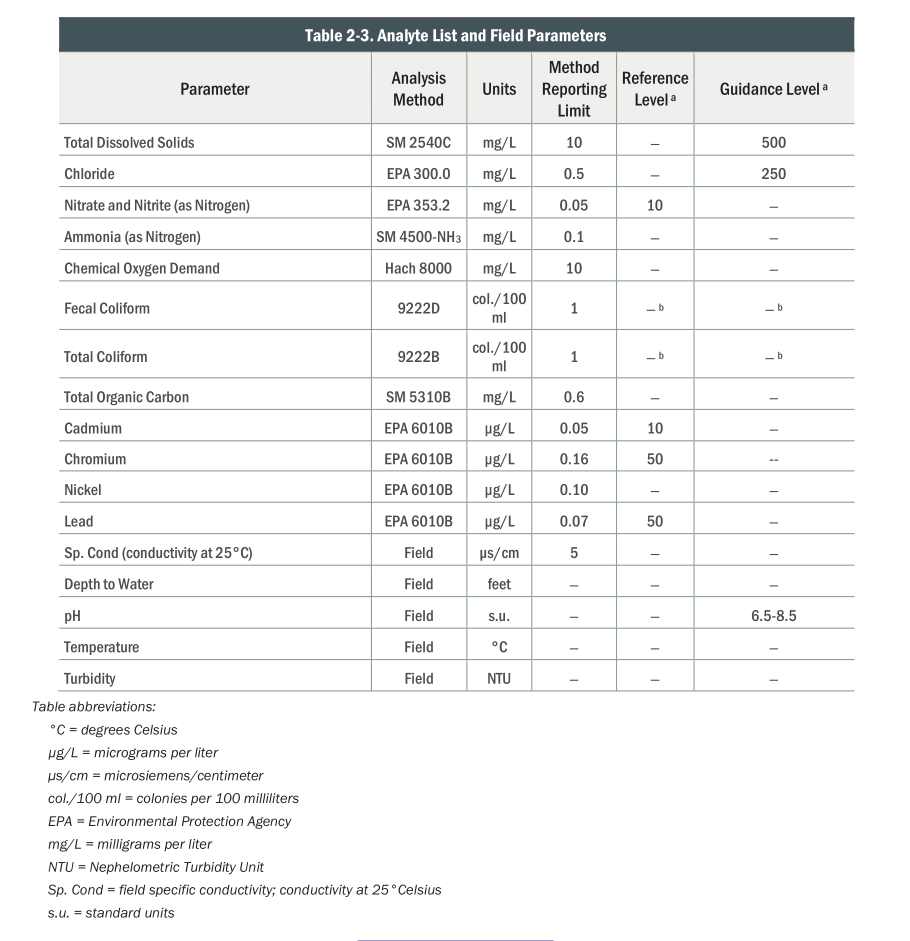)

## Overview of the data:

We’ve got:

-   Information about the wells:
    [BMF_Well_details_2023_GWMP.csv](../data/BMF_Well_details_2023_GWMP.csv)

-   The actual measurements:
    [Eugene_BiosolidsManagementFacility_GroundwaterData.csv](../data/Eugene_BiosolidsManagementFacility_GroundwaterData.csv)

## Set-up

In [ ]:
import pandas as pd
import numpy as np
import plotnine as p9
import folium, pyproj

# “Look at the data”, part 1

Game plan:

-   How many wells are there?
-   How many observations do we have from each, of what quantities, and
    over what time periods?
-   Where are the wells, and what do we know about them?

*Preliminary answers above; but let’s check this!*

## Measurements

-   Measurements often run into detection limits; this is conveyed as
    “censoring status”.
-   `well.name` is the name of the location with the first year it was
    in operation appended

``` sh
$ head data/Eugene_BiosolidsManagementFacility_GroundwaterData.csv | tr ',' '\t'
"well.name" "SampledDate"   "SampleNumber"  "ParameterName" "ParameterUnits"    "result"    "Method.Detection.Limit"    "Reporting.limit"   "censoring.status"  "Easting"   "Northing"
"MW-13-1988"    1988-01-25  "880050"    "Ammonia"   "mg/L"  0.1 NA  NA  "left.censored" 4218262.9   910814.599999998
"MW-13A-1988"   1988-01-25  "880052"    "Ammonia"   "mg/L"  0.1 NA  NA  "left.censored" 4218304.4   910813.2
"MW-14-1988"    1988-01-25  "880054"    "Ammonia"   "mg/L"  0.1 NA  NA  "left.censored" 4217612.3   910814.700000002
"MW-14A-1988"   1988-01-25  "880055"    "Ammonia"   "mg/L"  0.1 NA  NA  "left.censored" 4217622.5   910814.499999998
"MW-14B-1988"   1988-01-25  "880058"    "Ammonia"   "mg/L"  0.1 NA  NA  "left.censored" 4217612.9   910804.299999995
"MW-13-1988"    1988-01-25  "880050"    "Cadmium"   "µg/L"  1   NA  NA  "left.censored" 4218262.9   910814.599999998
"MW-13A-1988"   1988-01-25  "880052"    "Cadmium"   "µg/L"  1   NA  NA  "left.censored" 4218304.4   910813.2
"MW-14-1988"    1988-01-25  "880054"    "Cadmium"   "µg/L"  1   NA  NA  "left.censored" 4217612.3   910814.700000002
"MW-14A-1988"   1988-01-25  "880055"    "Cadmium"   "µg/L"  1   NA  NA  "left.censored" 4217622.5   910814.499999998
```

## Pull in the data

In [ ]:
gw = (
    pd.read_csv("data/Eugene_BiosolidsManagementFacility_GroundwaterData.csv")
    .convert_dtypes()
    .rename(columns=lambda x: x.replace(".", "_"))
    .assign(SampledDate = lambda df: pd.to_datetime(df['SampledDate']))
)
gw

## What’s measured?

In [ ]:
gw.groupby("ParameterName")['result'].describe()

## How many things are measured?

Tabular form:

In [ ]:
pd.crosstab(gw['well_name'], gw['ParameterName'])

## When was each well used?

In [ ]:
(
    pd.crosstab(gw['well_name'], gw['SampledDate'].dt.year)
    .reset_index()
    .melt(id_vars=['well_name'])
    .assign(year=lambda df: pd.to_numeric(df['SampledDate']))
    >>
    p9.ggplot(p9.aes(x='year', y='value', color='well_name'))
    + p9.geom_point() + p9.geom_line()
) + p9.theme(figure_size=(16,6))

## When was each thing measured?

In [ ]:
(
    pd.crosstab(gw['ParameterName'], gw['SampledDate'].dt.year)
    .reset_index()
    .melt(id_vars=['ParameterName'])
    .assign(year=lambda df: pd.to_numeric(df['SampledDate']))
    >>
    p9.ggplot(p9.aes(x='year', y='value', color='ParameterName'))
    + p9.geom_point() + p9.geom_line()
    + p9.labs(y='number of measurements')
    + p9.theme(figure_size=(16,6))
)

## Summary:

> How many observations do we have from each, of what quantities, and
> over what time periods?

*Exercise.*

# Where are the wells?

## Well info

``` sh
$ cat data/BMF_Well_details_2023_GWMP.csv | tr ',' '\t'
LocationName    well.orientation    well.depth.category screened.interval.feet
MW-7    downgradient    deep    42 to 52
MW-9    downgradient    shallow 15 to 25
MW-13A  downgradient    deep    30 to 50
MW-14   downgradient    deep    55 to 75
MW-14A  downgradient    deep    30 to 50
MW-14B  downgradient    shallow 10 to 25
MW-15   downgradient    deep    30 to 50
MW-18   downgradient    deep    30 to 50
MW-19   downgradient    deep    30 to 50
MW-19A  downgradient    shallow 10 to 25
MW-20   downgradient    shallow 10 to 25
MW-16   lateral deep    30 to 50
MW-17   lateral shallow 10 to 25
MW-21   lateral shallow 10 to 25
MW-10   upgradient  shallow 15 to 25
MW-11   upgradient  shallow 15 to 25
MW-12   upgradient  shallow 15 to 25
MW-22   upgradient  shallow 10 to 25
MW-13-2024  downgradient    shallow 10 to 25
```

## Get per-well summaries from this

We’d like the *location* to be in the per-well table, so let’s pull this
out of the “measurements” file first:

In [ ]:
gw_wells = (
    gw.groupby(['well_name', 'Easting', 'Northing'])
    .aggregate(
        n = ('SampleNumber', lambda x: len(x)),
    )
    .reset_index()
    .assign(
        LocationName = lambda df: "MW-" + df['well_name'].str.extract("-([0-9A-Z]*)-"),
        FirstYear = lambda df: df['well_name'].str.extract("-([0-9A-Z]*)$")
    )
)    
gw_wells.loc[gw_wells['well_name'] == "MW-13-2024", 'LocationName'] = "MW-13-2024"

## Well information

In [ ]:
wells = pd.merge(
    (
        pd.read_csv("data/BMF_Well_details_2023_GWMP.csv")
        .convert_dtypes()
        .rename(columns=lambda x: x.replace(".", "_"))
    ),
    gw_wells, how='outer', on='LocationName'
)
wells

## Mapping

Let’s use
[folium](https://python-visualization.github.io/folium/latest/index.html).
Looking at [the
documentation](https://python-visualization.github.io/folium/latest/reference.html#module-folium.folium),
we need a location in “*Latitude and Longitude of Map (Northing,
Easting)*”.

> Easting and Northing coordinates are provided in the [ESPG:
> 2270](https://spatialreference.org/ref/epsg/2270/) Coordinate
> Reference System (NAD83 / Oregon South (ft))

So first: find the center of the well locations, and project it to
lat/long.

In [ ]:
def transform(easting, northing):
    crs = pyproj.CRS.from_epsg(2270)
    latlon = pyproj.CRS(proj='latlon', datum='WGS84')
    transformer = pyproj.Transformer.from_crs(crs, latlon)
    y, x = transformer.transform(easting, northing)
    return (x, y)

center = transform(wells['Easting'].mean(), wells['Northing'].mean())
center

## The wells:

In [ ]:
folium.Map(location=center, zoom_start=16)

## Let’s get some more info on that:

After some iteration:

In [ ]:
import matplotlib

def add_marker(m, row=None, tooltip=None, location=None, **kwargs):
    defaults = {
        'radius': 10,
        'fill_color': "orange",
        'fill_opacity': 0.4,
        'color': 'black',
        'weight': 1
    }
    defaults.update(kwargs)
    if location is None:
        location = transform(row.Easting, row.Northing)
    if tooltip is None and row is not None:
        tooltip = row.LocationName
    return folium.CircleMarker(
        location=location,
        tooltip=tooltip,
        **defaults
    ).add_to(m)

def make_colormap(x, xmin=None, xmax=None, mapname='viridis'):
    cmap = matplotlib.colormaps[mapname]
    if xmin is None:
        xmin = np.min(x)
    if xmax is None:
        xmax = np.max(x)
    assert xmax > xmin, f"Must have xmin < xmax (got {xmin}, {xmax})."
    def f(x):
        colors = cmap((x - xmin)/(xmax - xmin))
        if isinstance(colors, tuple):
            colors = [colors]
        return [matplotlib.colors.to_hex(u) for u in colors]
    return f

well_bbox = (
    transform(wells['Easting'].min(), wells['Northing'].min()),
    transform(wells['Easting'].min(), wells['Northing'].max()),
    transform(wells['Easting'].max(), wells['Northing'].max()),
    transform(wells['Easting'].max(), wells['Northing'].min()),
)
def add_legend(m, colors, k=8, title=None):
    dy = (well_bbox[1][0] - well_bbox[0][0])/k
    pos = list(well_bbox[2])
    def text(pos, label):
        folium.Marker(
            pos,
            icon=folium.DivIcon(
                icon_size=(100,30),
                icon_anchor=(-15,15),
                html=f'<div style="font-size: 15pt">{label}</div>',
            )
        ).add_to(m)        
    if title is not None:
        text(pos, title)
        pos[0] -= dy
    for n in colors:
        add_marker(m, location=pos, fill_color=colors[n]).add_to(m)
        label = n if type(n) is str else 'NA'
        text(pos, label)
        pos[0] -= dy

## Well orientation:

In [ ]:
orientation_colors = {
    'upgradient' : "#66c2a5",
    'downgradient' : "#8da0cb",
    'lateral' : "#fc8d62",
    pd.NA : "#666666",
}

m = folium.Map(location=center, zoom_start=16)
add_legend(m, orientation_colors)
for r in wells.itertuples():
    add_marker(m, r,
        fill_color=orientation_colors[r.well_orientation],
    )

m

## Well depth:

In [ ]:
depth_colors = {
    'shallow' : "#7fc97f",
    'deep' : "#fdc086",
    pd.NA : "#666666",
}

m = folium.Map(location=center, zoom_start=16)
add_legend(m, depth_colors)
for r in wells.itertuples():
    add_marker( m, r,
        fill_color=depth_colors[r.well_depth_category],
    )

m

## Summary

> Where are the wells, and what do we know about them?

*Exercise*

# “Look at the data”, part 2

Game plan:

-   Do the measurements differ most:

    -   between wells?
    -   between types of well? (up/downgradient, shallow/deep)
    -   between years?
    -   between seasons?
    -   all/some of the above?

-   Do nearby wells get similar measurements?

## All the data, from 20,000 feet

In [ ]:
(
    p9.ggplot(gw, p9.aes(x="SampledDate", y="result", color='well_name'))
    + p9.geom_line() + p9.geom_point(size=0.2, alpha=0.25)
    + p9.facet_grid(rows="ParameterName", scales='free_y')
) + p9.theme(figure_size=(8,24))

## Observations?

What features do we see here and what do those features suggest doing?

*Exercise:*

1.  Filter out the obvious outliers (eg Chromium, can’t tell what’s
    going on).

2.  Which variables are most important to the audience of the report?

3.  Consider removing wells or variables for which we don’t have
    complete observations: for instance, Temperature.

4.  Conductivity:

    -   does the location relative to the plant,
    -   or type of well
    -   impact whether it’s increasing/decreasing long term,
    -   or whether it’s oscilating.

5.  Are the oscillations in various variables always going along with
    water level/season?

6.  Chloride: what happened with that one well that had very large
    values for a while?

## Set-up:

Let’s add well categories to the measurement data:

In [ ]:
gw = pd.merge(
    gw,
    wells.loc[:,('well_name', 'well_orientation', 'well_depth_category')],
    how='left',
    on='well_name'
)
gw.head()

# Outliers?

## Here’s Chromium:

In [ ]:
(
    gw
    .query("ParameterName == 'Chromium'")
    >> p9.ggplot(p9.aes(x="SampledDate", y="result", color="well_depth_category", group="well_name"))
    + p9.geom_line() + p9.geom_point(size=0.5, alpha=0.5)
) + p9.theme(figure_size=(9,4))

## Ways to deal with outliers in visualization

1.  Change the axis limits to zoom in on what you want.
2.  Transform the variable (e.g., with `log`).
3.  Programatically decide which ones are outliers and remove them.

-   Either the second or third methods sets you up for downstream
    analysis.
-   A transformation is better if it gives you “the right scale to look
    at the data on”.
-   The third method is good if you think the “outliers” are produced by
    some other process that is not of interest (for instance,
    measurement error).
-   A good generic way to do (3) is by computing $z$ scores:
    `z = (value - center)/scale`.

## Chromium, transformed

In [ ]:
(
    gw
    .query("ParameterName == 'Chromium'")
    >> p9.ggplot(p9.aes(x="SampledDate", y="result", color="well_depth_category", group="well_name"))
    + p9.geom_line() + p9.geom_point(size=0.5, alpha=0.5)
    + p9.labs(title="Chromium", y="concentration (µg/L)")
    + p9.scale_y_log10()
) + p9.theme(figure_size=(9,4))

## Chromium, “identifying outliers”?

`z = (value - center) / scale`

*Question:* what to use for “center” and “scale”? Median+IQR or mean+SD?
Within groups? Which groups?

-   Definitely group by year in this case, since things change.
-   Usually I’d prefer “median and IQR”, but for many years the IQR is
    zero.

In [ ]:
chromium = (
    gw.query("ParameterName == 'Chromium'")
    .assign(
        mean = lambda df: df['result'].groupby(df['SampledDate'].dt.year).transform('mean'),
        std = lambda df: df['result'].groupby(df['SampledDate'].dt.year).transform('std'),
        z = lambda df: (df['result'] - df['mean']) / ( df['std'] + (df['std'] == 0) ),
    )
)
chromium >> p9.ggplot(p9.aes(x='z')) + p9.geom_histogram(bins=40)

## How’s that look?

The cutoff for “outlier” in terms of $z$ scores should always be made
looking at the data, but often between 3 and 5 is good, if this is a
reasonable approach.

In [ ]:
p1 = (
    chromium
    >>
    p9.ggplot(p9.aes(x="SampledDate", y="result", group="well_name"))
    + p9.geom_line(alpha=0.5)
    + p9.geom_point(mapping=p9.aes(color="z.abs() > 5"))
    + p9.labs(title="Chromium", y="concentration (µg/L)")
)
p2 = (
    chromium
    .query("abs(z) < 5")
    >>
    p9.ggplot(p9.aes(x="SampledDate", y="result", group="well_name"))
    + p9.geom_line(alpha=0.5)
    + p9.geom_point()
    + p9.labs(title="Chromium", y="concentration (µg/L)")
)
(p1 / p2)

## All the heavy metals

In [ ]:
metals = ["Cadmium", "Chromium", "Copper", "Lead", "Nickel", "Zinc"]
(
    gw
    .loc[gw['ParameterName'].isin(metals), :]
    >> p9.ggplot(p9.aes(x="SampledDate", y="result", color="well_orientation", group="well_name"))
    + p9.geom_line() + p9.geom_point(size=0.5, alpha=0.5)
    + p9.scale_y_log10()
    + p9.facet_grid(rows="ParameterName")
) + p9.theme(figure_size=(9,12))

## All the heavy metals, since 2016

In [ ]:
(
    gw
    .loc[(gw['ParameterName'].isin(metals)) & (gw['SampledDate'].dt.year >= 2016), :]
    >> p9.ggplot(p9.aes(x="SampledDate", y="result", color="well_orientation", group="well_name"))
    + p9.geom_line() + p9.geom_point(size=0.5, alpha=0.5)
    + p9.scale_y_log10()
    + p9.facet_grid(rows="ParameterName", scales="free_y")
) + p9.theme(figure_size=(9,12))

## Takeaways?

-   
-   
-   

# Periodicity in water table elevation

Is the water table changing with the seasons? Looks like yes, although
when it starts to come up again in the Fall seems to differ by year.

In [ ]:
(
    gw
    .query("ParameterName == 'WaterTableElevation' and well_name == 'MW-17-1988'")
    >>
    p9.ggplot(p9.aes(x="SampledDate.dt.dayofyear", y="result", color='factor(SampledDate.dt.year)'))
    + p9.geom_point(size=0.5, alpha=0.75) + p9.geom_line()
    + p9.facet_wrap("well_name")
    + p9.labs(x='day of the year', y='level (ft)')
) + p9.theme(figure_size=(9,4))

##

In [ ]:
(
    gw
    .query("ParameterName == 'WaterTableElevation'")
    >>
    p9.ggplot(p9.aes(x="SampledDate.dt.dayofyear", y="result", color='factor(SampledDate.dt.year)'))
    + p9.geom_point(size=0.5, alpha=0.75) + p9.geom_line()
    + p9.facet_wrap("well_name")
    + p9.labs(x='day of the year', y='level (ft)')
) + p9.theme(figure_size=(9,15))

# Conductivity

Let’s dive into conductivity:

Does the:

-   location relative to the plant,
-   or type of well

impact whether it’s:

-   increasing/decreasing long term,
-   or oscilating.

In [ ]:
(
    gw.query("ParameterName == 'Conductivity'")
    >>
    p9.ggplot(p9.aes(x="SampledDate", y="result", color='well_depth_category', group='well_name'))
    + p9.geom_point(size=0.5, alpha=0.5) + p9.geom_line()
    + p9.labs(x='', y='conductivity (µS/cm)', title='Conductivity')
) + p9.theme(figure_size=(9,4))

## First step: separate out remove seasonal variation.

Model:

     value = seasonal + trend

In [ ]:
conductivity = (
    gw
    .query("ParameterName == 'Conductivity'")
    .assign(year = lambda df: df['SampledDate'].dt.year)
    .assign(mean_conductivity = lambda df: df.groupby(['well_name', 'year'])['result'].transform("mean"))
    .assign(diff_conductivity = lambda df: df['result'] - df['mean_conductivity'])
)

In [ ]:
(
    conductivity
    >>
    p9.ggplot(p9.aes(x="SampledDate", y="mean_conductivity", color='well_depth_category', group='well_name'))
    + p9.geom_point(size=0.2, alpha=0.25) + p9.geom_line()
    + p9.labs(x='', y='yearly mean', title='Conductivity (µS/cm)')
) / (
    conductivity
    >>
    p9.ggplot(p9.aes(x="SampledDate", y="diff_conductivity", color='well_depth_category', group='well_name'))
    + p9.geom_point(size=0.2, alpha=0.25) + p9.geom_line()
    + p9.labs(x='', y='seasonal difference')
) + p9.theme(figure_size=(9,6))

## Per-well variability

The most variable wells are shallow:

In [ ]:
csd = conductivity.groupby("well_name")['diff_conductivity'].std()
pd.merge(wells, pd.DataFrame(csd), on='well_name')[['well_name', 'diff_conductivity', 'well_orientation', 'well_depth_category']].sort_values("diff_conductivity")

## Where are they?

And, mostly downgradient?

In [ ]:
csdmap = make_colormap(csd.transform(np.log))
max_csd = csd.max()
legend_colors = { str(x) : csdmap(np.log(x)) for x in [1, int(max_csd/4), int(max_csd/2), int(max_csd*3/4), int(max_csd)] }

m = folium.Map(location=center, zoom_start=16)
for r in wells.itertuples():
    add_marker(
        m, r,
        fill_color=csdmap(np.log(csd[r.well_name])),
    )

add_legend(m, legend_colors, title='seasonality')
m

## Long-term trends:

Looks like the big increases in conductivity are all at deep wells.

In [ ]:
(
    conductivity
    >>
    p9.ggplot(p9.aes(x="SampledDate", y="mean_conductivity", color='well_name'))
    + p9.geom_point(size=0.2, alpha=0.25) + p9.geom_line()
    + p9.labs(x='', y='yearly mean', title='Conductivity (µS/cm)')
    + p9.facet_grid("well_depth_category")
)

## Takeaways?

-   
-   
-   

# What’s correlated with what?

*Question:* what is “what”?

Refined question: which variables are correlated with each other,
possibly considering seasonal variation or not?

## Take 1: Per-observation correlation

In [ ]:
wide_gw = (
    gw
    .set_index(['well_name', 'SampledDate', 'SampleNumber'])
    .loc[:,('ParameterName', 'ParameterUnits', 'result')]
    .pivot(columns='ParameterName', values='result')
    .reset_index()  
)
wide_gw.head()

## Take 1: The correlation matrix

In [ ]:
cormat = wide_gw.select_dtypes("float").corr()
cormat.style.background_gradient()

## Take 1: The correlation matrix, in a nice order:

In [ ]:
cormat = wide_gw.select_dtypes("float").corr()
pcs = np.linalg.eig(cormat)
vord = np.argsort(np.abs(pcs.eigenvectors[:,0]))[::-1]

cormat.iloc[vord,vord].style.background_gradient()

## Take 2: Per-year (average) correlation:

In [ ]:
yearly_gw = (
    gw
    .assign(year = lambda df: df['SampledDate'].dt.year)
    .set_index(['well_name', 'ParameterName'])
    .select_dtypes(("number", "datetime"))
    .groupby(['well_name', 'year', 'ParameterName'])
    .mean()
    .reset_index()
    .set_index(['well_name', 'SampledDate'])
    .loc[:,('ParameterName', 'result')]
    .pivot(columns='ParameterName', values='result')
    .reset_index()
)
yearly_gw.head()

## Take 2: correlation matrix

Cor(temperature, ammonia) is NA, so we omit it:

In [ ]:
cormat = yearly_gw.drop(columns="Temperature").select_dtypes("float").corr()
pcs = np.linalg.eig(cormat)
vord = np.argsort(np.abs(pcs.eigenvectors[:,0]))[::-1]
cormat.iloc[vord,vord].style.background_gradient()

## Take 3: Per-year averages, since 2016

In [ ]:
recent_gw = (
    gw
    .query("SampledDate >= '01-01-2016'")
    .assign(year = lambda df: df['SampledDate'].dt.year)
    .set_index(['well_name', 'ParameterName'])
    .select_dtypes(("number", "datetime"))
    .groupby(['well_name', 'year', 'ParameterName'])
    .mean()
    .reset_index()
    .set_index(['well_name', 'SampledDate'])
    .loc[:,('ParameterName', 'result')]
    .pivot(columns='ParameterName', values='result')
    .reset_index()
)
recent_gw.head()

## Take 3: correlation matrix

In [ ]:
cormat = recent_gw.drop(columns="Temperature").select_dtypes("float").corr()
pcs = np.linalg.eig(cormat)
vord = np.argsort(np.abs(pcs.eigenvectors[:,0]))[::-1]
cormat.iloc[vord,vord].style.background_gradient()

## Takeaways:

**Note:** two variables are strongly correlated here if they tend to
have larger-than-average values *in the same year-well combinations*.

So, this might be “the two variables are typically higher in the same
wells”, or “the two variables are typically higher in the same years”,
or some complicated combination.

# “Look at the data”, part 3?

*Next steps:* brainstorm!

Ideas? Questions?

> Do nearby wells get similar measurements?